In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import PercentFormatter
from scipy.linalg import expm
import warnings
warnings.filterwarnings('ignore')

# ── Global Dark Style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#0F1117',
    'axes.facecolor':    '#1A1D27',
    'axes.edgecolor':    '#3A3D4D',
    'axes.labelcolor':   '#E0E0E0',
    'axes.titlesize':    14,
    'axes.titleweight':  'bold',
    'axes.titlecolor':   '#FFFFFF',
    'axes.labelsize':    11,
    'xtick.color':       '#B0B0B0',
    'ytick.color':       '#B0B0B0',
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'grid.color':        '#2A2D3D',
    'grid.linestyle':    '--',
    'grid.alpha':        0.6,
    'text.color':        '#E0E0E0',
    'legend.facecolor':  '#1A1D27',
    'legend.edgecolor':  '#3A3D4D',
    'legend.fontsize':   9,
    'font.family':       'DejaVu Sans',
})

COLORS = {
    'full':    '#00D4AA',   # teal-green  — Full capacity
    'derated': '#FFB347',   # amber       — Derated / partial
    'forced':  '#FF6B6B',   # coral-red   — Forced outage
    'planned': '#7B9FFF',   # soft blue   — Planned maintenance
    'accent':  '#E040FB',   # purple      — highlights
}
print('✅  Style configured.')

✅  Style configured.


In [2]:
STATE_NAMES    = ['Full\nOperation', 'Derated\n(Partial)', 'Forced\nOutage', 'Planned\nMaintenance']
STATE_LABELS   = ['S0: Full', 'S1: Derated', 'S2: Forced Out', 'S3: Planned Maint.']
CAPACITY_RATED = 100.0
CAPACITY_FRAC  = np.array([1.00, 0.60, 0.00, 0.00])
N              = len(STATE_NAMES)

# Transition Rate Matrix Q (per hour)
Q = np.array([
    [-0.050,  0.020,  0.020,  0.010],   # from S0
    [ 0.030, -0.060,  0.020,  0.010],   # from S1
    [ 0.080,  0.040, -0.130,  0.010],   # from S2
    [ 0.060,  0.020,  0.010, -0.090],   # from S3
])

# Verify rows sum to 0
assert np.allclose(Q.sum(axis=1), 0, atol=1e-9), "Row sums must be 0!"

df_Q = pd.DataFrame(Q,
    index  =['From ' + s.replace('\n',' ') for s in STATE_NAMES],
    columns=['To '   + s.replace('\n',' ') for s in STATE_NAMES])
print('Transition Rate Matrix Q:\n', df_Q.to_string(float_format='{:.4f}'.format))

Transition Rate Matrix Q:
                           To Full Operation  To Derated (Partial)  To Forced Outage  To Planned Maintenance
From Full Operation                 -0.0500                0.0200            0.0200                  0.0100
From Derated (Partial)               0.0300               -0.0600            0.0200                  0.0100
From Forced Outage                   0.0800                0.0400           -0.1300                  0.0100
From Planned Maintenance             0.0600                0.0200            0.0100                 -0.0900


In [3]:
def steady_state(Q: np.ndarray) -> np.ndarray:
    """Solve π·Q = 0, Σπ = 1 for steady-state distribution."""
    n = Q.shape[0]
    A = Q.T.copy()
    A[-1, :] = 1.0
    b = np.zeros(n); b[-1] = 1.0
    pi = np.linalg.solve(A, b)
    pi = np.abs(pi)
    pi /= pi.sum()
    return pi

pi = steady_state(Q)
capacity_factor = float(np.dot(pi, CAPACITY_FRAC))

df_results = pd.DataFrame({
    'State':              [s.replace('\n',' ') for s in STATE_NAMES],
    'Capacity (MW)':      CAPACITY_FRAC * CAPACITY_RATED,
    'Capacity Fraction':  CAPACITY_FRAC,
    'Steady-State Prob.': pi,
    'CF Contribution':    pi * CAPACITY_FRAC,
})
print(df_results.to_string(index=False, float_format='{:.6f}'.format))
print(f'\n⚡  Capacity Factor = {capacity_factor:.4f}  ({capacity_factor*100:.2f}%)')

              State  Capacity (MW)  Capacity Fraction  Steady-State Prob.  CF Contribution
     Full Operation     100.000000           1.000000            0.491667         0.491667
  Derated (Partial)      60.000000           0.600000            0.281667         0.169000
      Forced Outage       0.000000           0.000000            0.126667         0.000000
Planned Maintenance       0.000000           0.000000            0.100000         0.000000

⚡  Capacity Factor = 0.6607  (66.07%)


In [4]:
t_max, t_steps = 200, 500
t_grid = np.linspace(0, t_max, t_steps)
pi0    = np.array([1.0, 0.0, 0.0, 0.0])   # start: Full Operation

prob_t = np.clip(np.array([pi0 @ expm(Q * t) for t in t_grid]), 0, 1)
cf_t   = prob_t @ CAPACITY_FRAC

print(f'Steady-state CF (analytical): {capacity_factor*100:.3f}%')
print(f'CF at t={t_max}h  (numerical): {cf_t[-1]*100:.3f}%')

Steady-state CF (analytical): 66.067%
CF at t=200h  (numerical): 66.067%


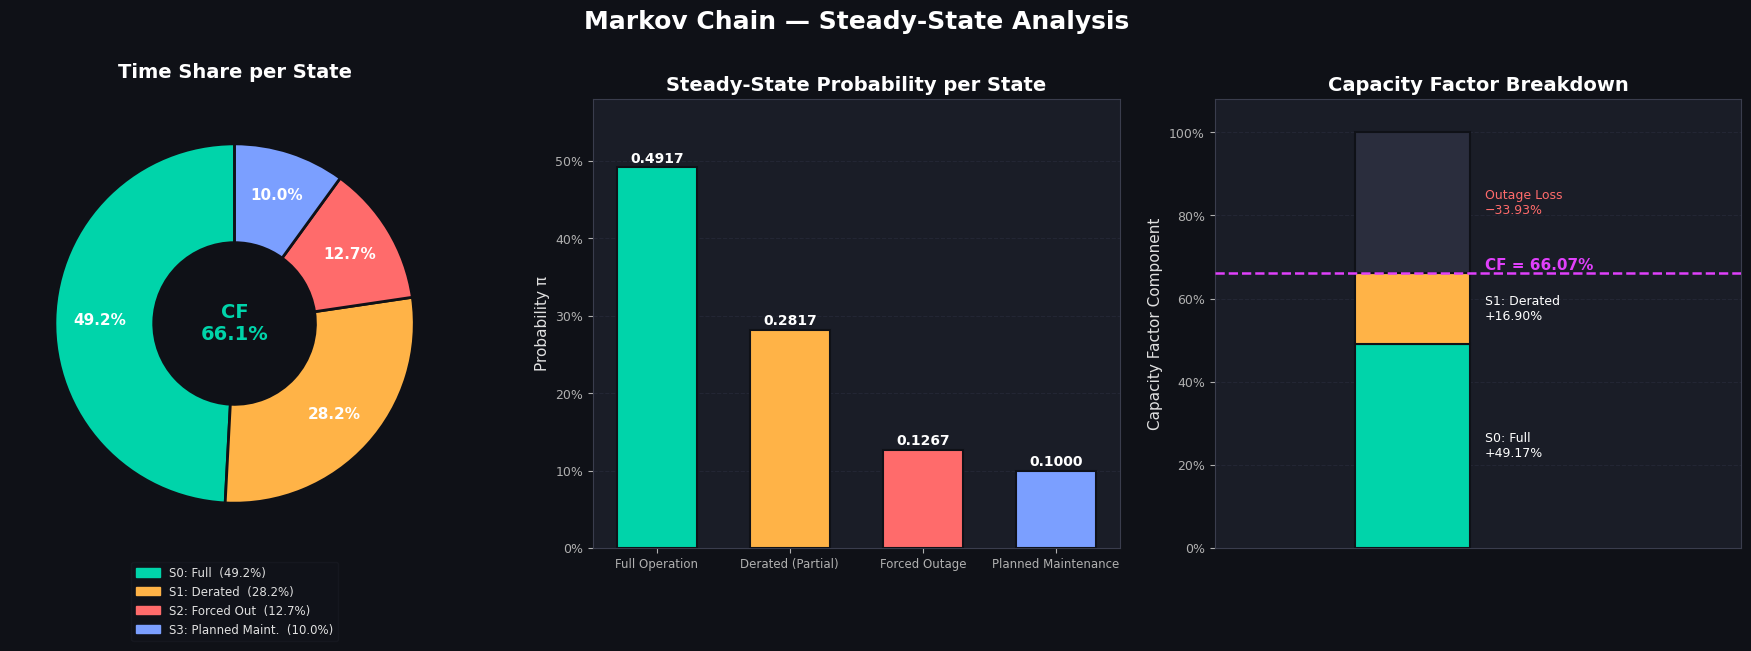

In [5]:
state_colors = [COLORS['full'], COLORS['derated'], COLORS['forced'], COLORS['planned']]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#0F1117')
fig.suptitle('Markov Chain — Steady-State Analysis', fontsize=18,
             fontweight='bold', color='white', y=1.02)

# (a) Donut chart
ax = axes[0]
ax.set_facecolor('#0F1117')
wedges, texts, autotexts = ax.pie(
    pi, colors=state_colors, autopct='%1.1f%%', startangle=90,
    pctdistance=0.75, wedgeprops=dict(width=0.55, edgecolor='#0F1117', linewidth=2))
for at in autotexts:
    at.set(fontsize=11, fontweight='bold', color='white')
patches = [mpatches.Patch(color=state_colors[i],
           label=f'{STATE_LABELS[i]}  ({pi[i]*100:.1f}%)') for i in range(N)]
ax.legend(handles=patches, loc='lower center', bbox_to_anchor=(0.5, -0.22),
          framealpha=0.15, fontsize=8.5)
ax.text(0, 0, f'CF\n{capacity_factor*100:.1f}%', ha='center', va='center',
        fontsize=14, fontweight='bold', color=COLORS['full'])
ax.set_title('Time Share per State', pad=15)

# (b) Bar chart
ax = axes[1]
bars = ax.bar(range(N), pi, color=state_colors, edgecolor='#0F1117',
              linewidth=1.5, width=0.6, zorder=3)
for bar, val in zip(bars, pi):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10,
            fontweight='bold', color='white')
ax.set_xticks(range(N))
ax.set_xticklabels([s.replace('\n',' ') for s in STATE_NAMES], fontsize=8.5)
ax.set_ylabel('Probability π')
ax.set_title('Steady-State Probability per State')
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.grid(axis='y', zorder=0)
ax.set_ylim(0, max(pi)*1.18)

# (c) CF breakdown stacked bar
ax = axes[2]
bottom, cf_contrib = 0, pi * CAPACITY_FRAC
for i in range(N):
    if cf_contrib[i] > 0:
        ax.bar(0, cf_contrib[i], bottom=bottom, color=state_colors[i],
               width=0.35, edgecolor='#0F1117', linewidth=1.5, zorder=3)
        ax.text(0.22, bottom + cf_contrib[i]/2,
                f'{STATE_LABELS[i]}\n+{cf_contrib[i]*100:.2f}%',
                va='center', fontsize=9, color='white')
        bottom += cf_contrib[i]
outage = 1 - capacity_factor
ax.bar(0, outage, bottom=capacity_factor, color='#2A2D3D',
       width=0.35, edgecolor='#0F1117', linewidth=1.5, zorder=3)
ax.text(0.22, capacity_factor + outage/2,
        f'Outage Loss\n−{outage*100:.2f}%', va='center', fontsize=9, color='#FF6B6B')
ax.axhline(capacity_factor, color=COLORS['accent'], lw=1.8, ls='--', zorder=4)
ax.text(0.22, capacity_factor + 0.01, f'CF = {capacity_factor*100:.2f}%',
        color=COLORS['accent'], fontsize=11, fontweight='bold')
ax.set_xlim(-0.6, 1.0); ax.set_xticks([])
ax.set_ylabel('Capacity Factor Component')
ax.set_title('Capacity Factor Breakdown')
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylim(0, 1.08); ax.grid(axis='y', zorder=0)

plt.tight_layout()
plt.show()

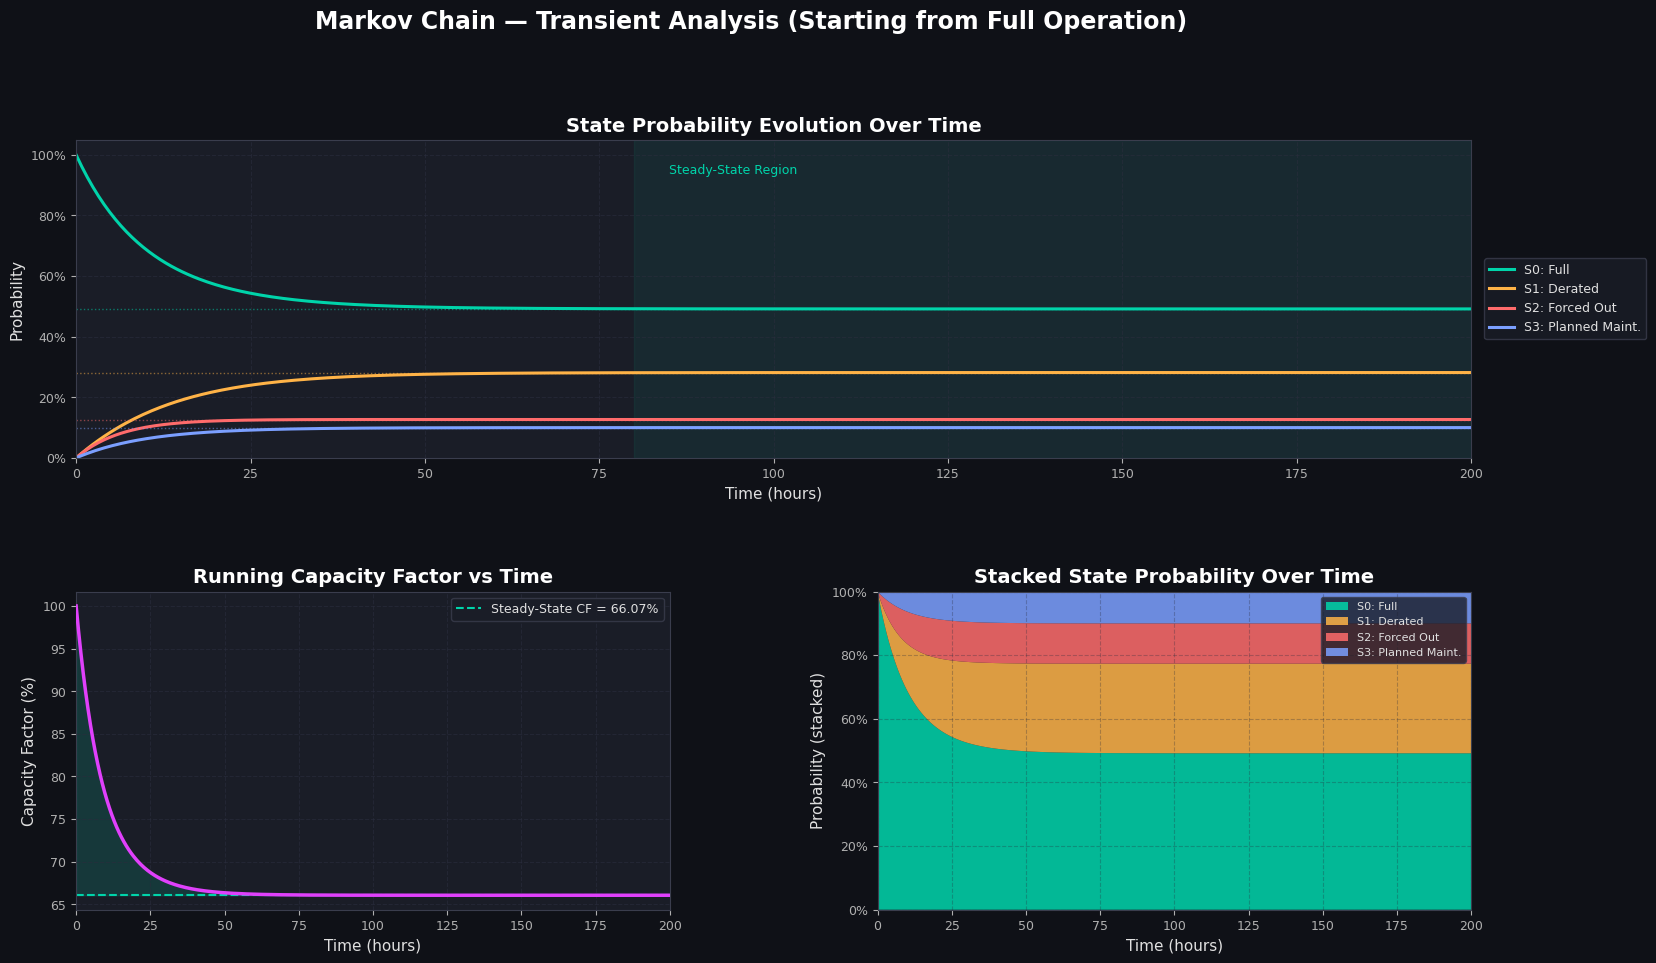

In [6]:
fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor('#0F1117')
fig.suptitle('Markov Chain — Transient Analysis (Starting from Full Operation)',
             fontsize=17, fontweight='bold', color='white', y=1.01)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.35)

# (a) Probability evolution
ax1 = fig.add_subplot(gs[0, :])
for i in range(N):
    ax1.plot(t_grid, prob_t[:, i], color=state_colors[i], lw=2.2, label=STATE_LABELS[i])
    ax1.axhline(pi[i], color=state_colors[i], lw=1, ls=':', alpha=0.5)
ax1.axvspan(80, t_max, alpha=0.07, color=COLORS['full'])
ax1.text(85, 0.97, 'Steady-State Region', fontsize=9, color=COLORS['full'], va='top')
ax1.set_xlabel('Time (hours)'); ax1.set_ylabel('Probability')
ax1.set_title('State Probability Evolution Over Time')
ax1.yaxis.set_major_formatter(PercentFormatter(1.0))
ax1.legend(loc='right', bbox_to_anchor=(1.13, 0.5))
ax1.grid(True); ax1.set_xlim(0, t_max); ax1.set_ylim(0, 1.05)

# (b) Running CF
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(t_grid, cf_t * 100, color=COLORS['accent'], lw=2.5, zorder=3)
ax2.axhline(capacity_factor*100, color=COLORS['full'], lw=1.5, ls='--',
            label=f'Steady-State CF = {capacity_factor*100:.2f}%')
ax2.fill_between(t_grid, cf_t*100, capacity_factor*100,
                 where=(cf_t > capacity_factor), alpha=0.15, color=COLORS['full'])
ax2.fill_between(t_grid, cf_t*100, capacity_factor*100,
                 where=(cf_t < capacity_factor), alpha=0.15, color=COLORS['forced'])
ax2.set_xlabel('Time (hours)'); ax2.set_ylabel('Capacity Factor (%)')
ax2.set_title('Running Capacity Factor vs Time')
ax2.legend(fontsize=9); ax2.grid(True); ax2.set_xlim(0, t_max)

# (c) Stacked area
ax3 = fig.add_subplot(gs[1, 1])
ax3.stackplot(t_grid, prob_t.T, labels=STATE_LABELS, colors=state_colors, alpha=0.85)
ax3.set_xlabel('Time (hours)'); ax3.set_ylabel('Probability (stacked)')
ax3.set_title('Stacked State Probability Over Time')
ax3.yaxis.set_major_formatter(PercentFormatter(1.0))
ax3.legend(loc='upper right', fontsize=8)
ax3.grid(True, alpha=0.3); ax3.set_xlim(0, t_max); ax3.set_ylim(0, 1)

plt.tight_layout()
plt.show()

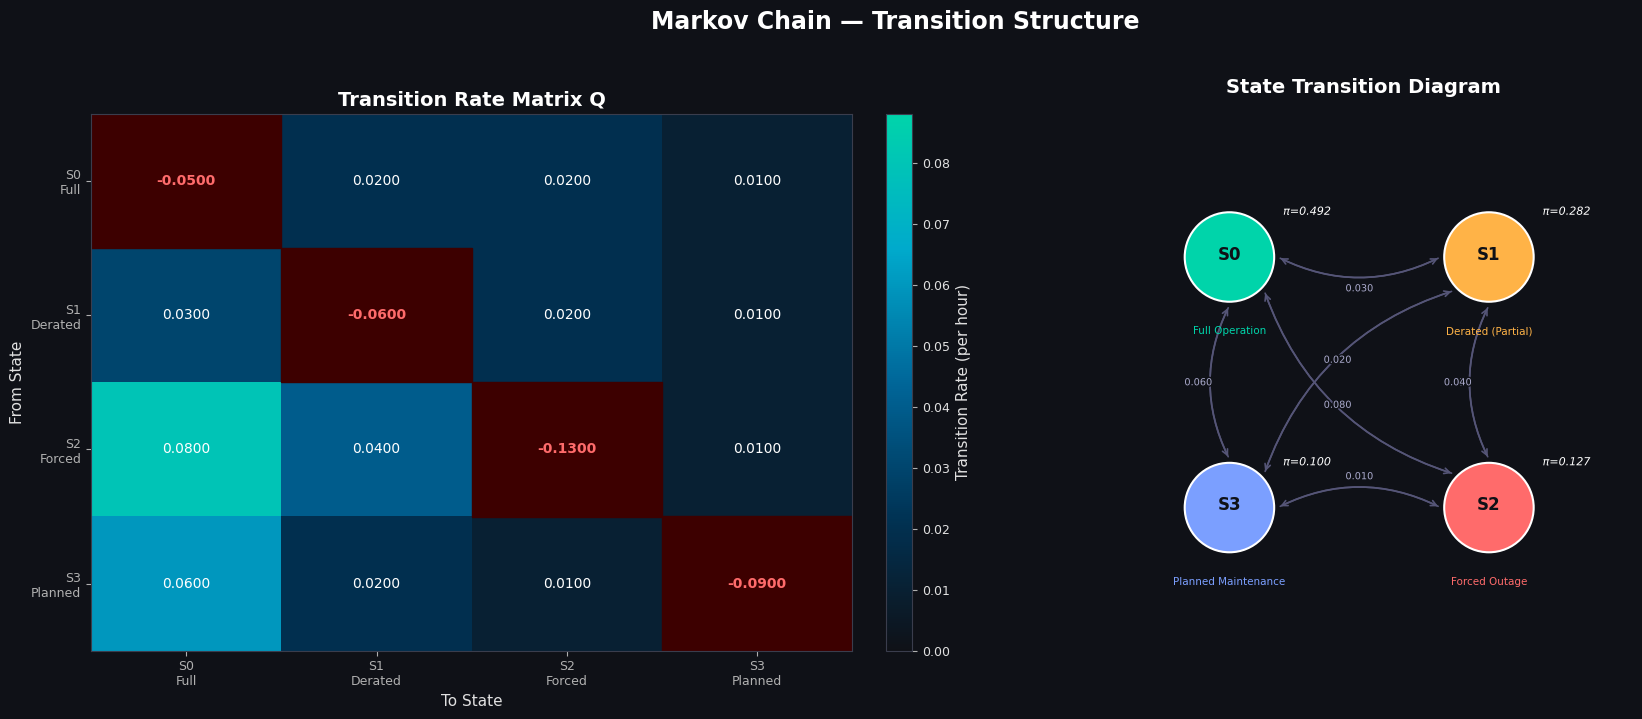

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#0F1117')
fig.suptitle('Markov Chain — Transition Structure', fontsize=17,
             fontweight='bold', color='white', y=1.02)

# (a) Heatmap
ax = axes[0]
short = ['S0\nFull', 'S1\nDerated', 'S2\nForced', 'S3\nPlanned']
cmap = LinearSegmentedColormap.from_list('rg',
    ['#0F1117','#003355','#006699','#00AACC','#00D4AA'], N=256)
mask_off = Q.copy(); np.fill_diagonal(mask_off, np.nan)
im = ax.imshow(mask_off, cmap=cmap, aspect='auto', vmin=0, vmax=np.nanmax(mask_off)*1.1)
for i in range(N):
    ax.add_patch(plt.Rectangle((i-0.5,i-0.5), 1, 1, color='#3D0000', zorder=1))
for i in range(N):
    for j in range(N):
        ax.text(j, i, f'{Q[i,j]:.4f}', ha='center', va='center', fontsize=10,
                color='#FF6B6B' if i==j else 'white',
                fontweight='bold' if i==j else 'normal', zorder=2)
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Transition Rate (per hour)', color='#E0E0E0')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#E0E0E0')
ax.set_xticks(range(N)); ax.set_xticklabels(short)
ax.set_yticks(range(N)); ax.set_yticklabels(short)
ax.set_xlabel('To State'); ax.set_ylabel('From State')
ax.set_title('Transition Rate Matrix Q')

# (b) State diagram
ax = axes[1]
ax.set_facecolor('#0F1117')
ax.set_xlim(-0.1,1.1); ax.set_ylim(-0.1,1.1)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('State Transition Diagram', pad=15)
pos = np.array([[0.2,0.78],[0.78,0.78],[0.78,0.22],[0.2,0.22]])
R = 0.10
for i in range(N):
    for j in range(N):
        if i==j or Q[i,j]==0: continue
        xi,yi=pos[i]; xj,yj=pos[j]
        dx,dy=xj-xi,yj-yi; dist=np.hypot(dx,dy); ux,uy=dx/dist,dy/dist
        xs,ys=xi+ux*R*1.08,yi+uy*R*1.08; xe,ye=xj-ux*R*1.08,yj-uy*R*1.08
        rad = 0.25 if i < j else -0.25
        ax.annotate('',xy=(xe,ye),xytext=(xs,ys),
            arrowprops=dict(arrowstyle='->',color='#555577',lw=1.2,
                            connectionstyle=f'arc3,rad={rad}'))
        mx=(xs+xe)/2+(uy*0.07*np.sign(rad)); my=(ys+ye)/2-(ux*0.07*np.sign(rad))
        ax.text(mx,my,f'{Q[i,j]:.3f}',ha='center',va='center',fontsize=7,
                color='#AAAACC',
                path_effects=[pe.withStroke(linewidth=2,foreground='#0F1117')])
for i,(x,y) in enumerate(pos):
    ax.add_patch(plt.Circle((x,y),R,color=state_colors[i],ec='white',lw=1.5,zorder=5))
    ax.text(x,y+0.005,f'S{i}',ha='center',va='center',
            fontsize=12,fontweight='bold',color='#0F1117',zorder=6)
    ax.text(x,y-0.155,STATE_NAMES[i].replace('\n',' '),ha='center',va='top',
            fontsize=7.5,color=state_colors[i],zorder=6)
    ax.text(x+0.12,y+0.09,f'π={pi[i]:.3f}',ha='left',va='bottom',
            fontsize=8,color='white',style='italic',zorder=6,
            path_effects=[pe.withStroke(linewidth=2,foreground='#0F1117')])

plt.tight_layout()
plt.show()

ValueError: 'transform' is not allowed as a keyword argument; axhline generates its own transform.

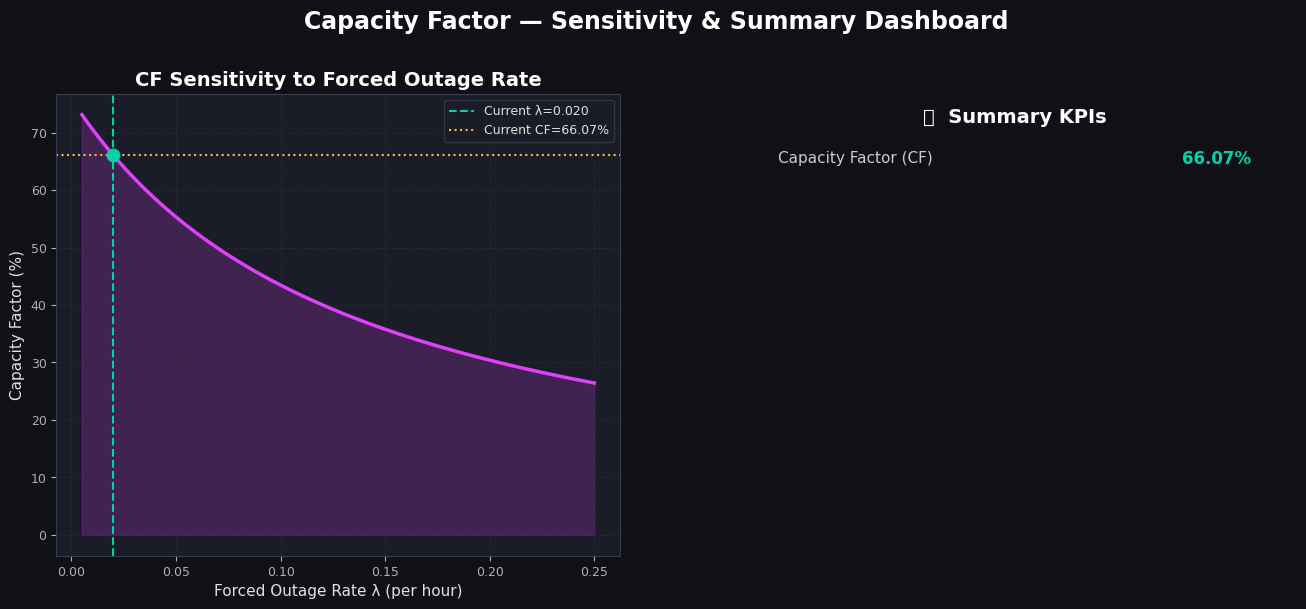

In [8]:
for_rates = np.linspace(0.005, 0.25, 60)
cf_sens = []
for lam in for_rates:
    Q_s = Q.copy()
    d0=lam-Q[0,2]; d1=lam-Q[1,2]
    Q_s[0,2]+=d0; Q_s[0,0]-=d0
    Q_s[1,2]+=d1; Q_s[1,1]-=d1
    try:
        cf_sens.append(np.dot(steady_state(Q_s), CAPACITY_FRAC)*100)
    except:
        cf_sens.append(np.nan)
cf_sens = np.array(cf_sens)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0F1117')
fig.suptitle('Capacity Factor — Sensitivity & Summary Dashboard',
             fontsize=17, fontweight='bold', color='white', y=1.02)

# (a) Sensitivity
ax = axes[0]
ax.plot(for_rates, cf_sens, color=COLORS['accent'], lw=2.5, zorder=3)
ax.fill_between(for_rates, cf_sens, alpha=0.2, color=COLORS['accent'])
ax.axvline(Q[0,2], color=COLORS['full'], ls='--', lw=1.5, label=f'Current λ={Q[0,2]:.3f}')
ax.axhline(capacity_factor*100, color=COLORS['derated'], ls=':', lw=1.5,
           label=f'Current CF={capacity_factor*100:.2f}%')
ax.scatter([Q[0,2]], [capacity_factor*100], s=80, color=COLORS['full'], zorder=5)
ax.set_xlabel('Forced Outage Rate λ (per hour)')
ax.set_ylabel('Capacity Factor (%)')
ax.set_title('CF Sensitivity to Forced Outage Rate')
ax.legend(fontsize=9); ax.grid(True)

# (b) KPI dashboard
ax = axes[1]; ax.axis('off')
kpis = [
    ('Capacity Factor (CF)',   f'{capacity_factor*100:.2f}%',          COLORS['full']),
    ('Unavailability',         f'{(1-capacity_factor)*100:.2f}%',      COLORS['forced']),
    ('P(Full Operation)',      f'{pi[0]*100:.2f}%',                    COLORS['full']),
    ('P(Derated)',             f'{pi[1]*100:.2f}%',                    COLORS['derated']),
    ('P(Forced Outage)',       f'{pi[2]*100:.2f}%',                    COLORS['forced']),
    ('P(Planned Maintenance)', f'{pi[3]*100:.2f}%',                    COLORS['planned']),
    ('Avg. Capacity (MW)',     f'{capacity_factor*CAPACITY_RATED:.1f} MW', COLORS['accent']),
    ('Rated Capacity',         f'{CAPACITY_RATED:.0f} MW',             '#888888'),
]
ax.text(0.5, 0.97, '📋  Summary KPIs', ha='center', va='top',
        fontsize=14, fontweight='bold', color='white', transform=ax.transAxes)
for k,(label,value,color) in enumerate(kpis):
    y = 0.97 - 0.11*(k+1)
    ax.text(0.08, y, label, ha='left', va='center', fontsize=11,
            color='#CCCCCC', transform=ax.transAxes)
    ax.text(0.92, y, value, ha='right', va='center', fontsize=12,
            fontweight='bold', color=color, transform=ax.transAxes)
    ax.axhline(y-0.045, xmin=0.05, xmax=0.95, color='#2A2D3D',
               lw=0.8, transform=ax.transAxes)
ax.add_patch(mpatches.FancyBboxPatch((0.03,0.04), 0.94, 0.88,
    boxstyle='round,pad=0.02', linewidth=1.5, edgecolor='#3A3D4D',
    facecolor='#1A1D27', transform=ax.transAxes, zorder=0))

plt.tight_layout()
plt.show()